[ 0.1661 31.3836  1.1275] [ 0.1086 82.2049] [40. 30.  0. 30.] [0.00342277 0.         1.        ]


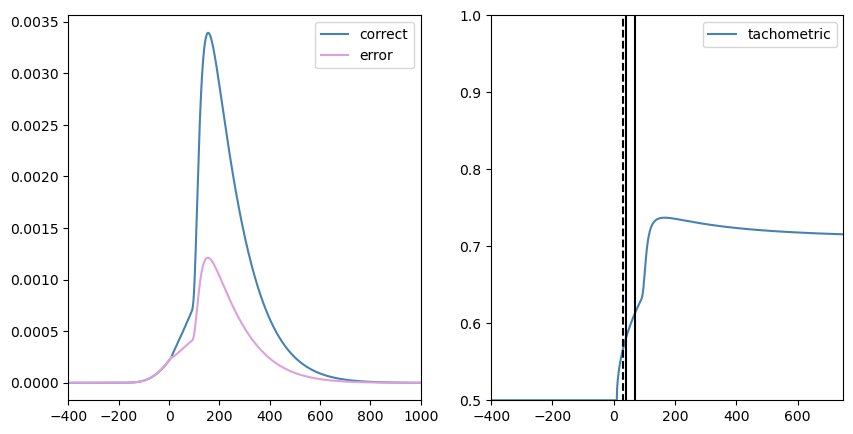

0.0007507000000259723
-15838.381072653925


In [21]:
import numpy as np
from numpy import pi, sin, cos, exp, sqrt, log
from scipy.special import erfcx, erfc


# %%

class model_tach_4delays:

    def __init__(self,RT,mu,t_fix=200,out=1.0, \
                compressive_power = 0.1,a_tied = 20,T0 = 2,v = 0.12,a = 60, \
                tse_TIED = 30,tmotor_TIED = 50,tse_PA = 30, tmotor_PA = 25, Delta=0, \
                b=5e-3, c=1e-3, d=.5, \
                full_readout = True, use_Delta = True):
        """
        Initialize the model with data and parameters
        """

        self.RT = RT
        # self.ABL = ABL
        self.ABL = np.log10((self.t_theta * self.T0 * a_tied**2) / 2) * (20/c)
        # self.ILD = ILD
        self.ILD = (40 / (np.log(10) * c * a_tied)) * mu
        self.t_fix = t_fix
        self.out = out #outcome or success

        # TIED
        self.compressive_power = compressive_power #lambda
        self.a_tied = a_tied #tied bound
        self.T0 = T0 #T0
        # PA
        self.v = v
        self.a = a
        # delays
        self.tse_TIED = tse_TIED
        self.tmotor_TIED = tmotor_TIED
        self.tse_PA = tse_PA
        self.tmotor_PA = tmotor_PA
        self.Delta = Delta
        # contaminants
        self.b = b #rate of the exponential
        self.c = c #fraction of contaminants
        self.d = d #fraction of exponential vs uniform component
        # settings for readout dynamics
        self.full_readout = full_readout #to use the readout at the end of the processing or at RT
        self.use_Delta = use_Delta #to use Delta to determine the duration of extra processing or not

        self.params_TIED = np.array([self.compressive_power,self.a_tied,self.T0])
        self.params_PA = np.array([self.v,self.a])
        self.params_delays = np.array([self.tse_TIED,self.tmotor_TIED,self.tse_PA,self.tmotor_PA])
        self.params_contaminants = np.array([self.b,self.c,self.d])

        self.t_theta = 2 * 10 ** (self.compressive_power * self.ABL / 20) / (self.T0 * self.a_tied ** 2)
        self.mu = self.ILD * self.compressive_power * self.a_tied / (40 / np.log(10))

        self.t_theta_pa = 1/self.a**2
        self.mu_pa = self.v*self.a

    def set_params(self, params):
        """
        Pass the model parameters in an array or list
        """

        compressive_power, a_tied, T0, v, a, tse_TIED, tmotor_TIED, tse_PA, tmotor_PA, Delta, \
        b, c, d, full_readout, use_Delta = params

        # TIED
        self.compressive_power = compressive_power
        self.a_tied = a_tied
        self.T0 = T0
        # PA
        self.v = v
        self.a = a
        # delays
        self.tse_TIED = tse_TIED
        self.tmotor_TIED = tmotor_TIED
        self.tse_PA = tse_PA
        self.tmotor_PA = tmotor_PA
        self.Delta = Delta
        # contaminants
        self.b = b
        self.c = c
        self.d = d
        # settings for readout dynamics
        self.full_readout = full_readout
        self.use_Delta = use_Delta

        self.params_TIED = np.array([self.compressive_power,self.a_tied,self.T0])
        self.params_PA = np.array([self.v,self.a])
        self.params_delays = np.array([self.tse_TIED,self.tmotor_TIED,self.tse_PA,self.tmotor_PA])
        self.params_contaminants = np.array([self.b,self.c,self.d])

        self.t_theta = 2 * 10 ** (self.compressive_power * self.ABL / 20) / (self.T0 * self.a_tied ** 2)
        self.mu = self.ILD * self.compressive_power * self.a_tied / (40 / np.log(10))

        self.t_theta_pa = 1/self.a**2
        self.mu_pa = self.v*self.a


    def set_params_TIED(self, params_TIED):
        """
        Pass the TIED parameters in an array or list
        """

        compressive_power, a_tied, T0 = params_TIED
        self.compressive_power = compressive_power
        self.a_tied = a_tied
        self.T0 = T0
        self.params_TIED = np.array([self.compressive_power,self.a_tied,self.T0])

        self.t_theta = 2 * 10 ** (self.compressive_power * self.ABL / 20) / (self.T0 * self.a_tied ** 2)
        self.mu = self.ILD * self.compressive_power * self.a_tied / (40 / np.log(10))

    def set_params_PA(self, params_PA):
        """
        Pass the PA parameters in an array or list
        """

        v, a = params_PA
        self.v = v
        self.a = a
        self.params_PA = np.array([self.v,self.a])

        self.t_theta_pa = 1/self.a**2
        self.mu_pa = self.v*self.a

    def set_params_delays(self, params_delays):
        """
        Pass the delay parameters in an array or list
        """

        tse_TIED, tmotor_TIED, tse_PA, tmotor_PA = params_delays
        self.tse_TIED = tse_TIED
        self.tmotor_TIED = tmotor_TIED
        self.tse_PA = tse_PA
        self.tmotor_PA = tmotor_PA
        self.params_delays = np.array([self.tse_TIED,self.tmotor_TIED,self.tse_PA,self.tmotor_PA])

    def set_params_contaminants(self, params_contaminants):
        """
        Pass the contaminant parameters in an array or list
        """

        b, c, d = params_contaminants
        self.b = b
        self.c = c
        self.d = d
        self.params_contaminants = np.array([self.b,self.c,self.d])

    def print_params(self):
        """
        Print the parameters
        """
        print(self.params_TIED, self.params_PA, self.params_delays, self.params_contaminants)

    def update_data(self,RT,ABL,ILD,t_fix,out):
        """
        Update the data (TBD: implement passing directly a data frame)
        """
        self.RT = RT
        self.ABL = ABL
        self.ILD = ILD
        self.t_fix = t_fix
        self.out = out #outcome or success


    # raw functions -> normalized time
    def f_and_F_raw_all_tied(self, t2):
        """
        Calculate raw for TIED PDF and CDF, for both choices.
        """
        # t = self.t_theta * (t2 - tND)
        t = self.t_theta * (t2)


        t_cut = 0.25 # transition point from short to long series
        K = 4  # Number of terms

        S2 = np.zeros_like(t,dtype=np.double)
        S1 = np.zeros_like(t,dtype=np.double)
        inds0 = t < 0
        inds1 = np.logical_and(t>0,t<=t_cut)
        inds2 = t > t_cut
        ts = t[inds1]
        tl = t[inds2]
        # t[inds0] = 0

        mu = self.mu
        mu2 = mu**2

        mus = (mu[inds1] if np.size(mu) > 1 else mu) # [inds1] for vec
        C1s = mus * ts
        C2s = 1.0 / (2 * ts)
        C3s = 1.0 / sqrt(2 * ts)

        mu2l = (mu2[inds2] if np.size(mu) > 1 else mu2)# [inds2] for vec
        C1l = pi / 4
        C2l = pi ** 2 * tl / 8

        FS2 = np.zeros_like(t,dtype=np.double)
        FS1 = np.zeros_like(t,dtype=np.double)

        # this is the term that appears multiplying outside the sum in all the expressions
        ExpTerm_ = np.where(t<0,0,(exp(mu)+exp(-mu)) * exp(-mu2 / 2 * t))
        # ExpTerm_ = (exp(mu)+exp(-mu)) * exp(-mu2 * t / 2)
        # ExpTerm_[inds0] = 0

        for k in range(K):
            r = 2 * k + 1
            #for pdf
            # small times, this implements the sum part of Eq. 6.1.8
            S1[inds1] += (-1) ** k * r * exp(-r ** 2 * C2s)
            # large times, this implements the sum part of Eq. 6.1.3
            S2[inds2] += (-1) ** k * r * exp(-r ** 2 * C2l)

            # for CDF
            # small times, this implements the sum part of Eq. 6.2.7
            M = erfcx((r - C1s)*C3s) + erfcx((r + C1s)*C3s)
            SS = (-1) ** k * exp(-r ** 2 / (2 * ts)) * M
            FS1[inds1] += SS
            # large times, this implements the sum part of Eq. 6.2.3
            Ck = (pi * r / 2) ** 2
            SS = r * (-1) ** k * exp(-Ck * tl / 2) / (mu2l + Ck)
            FS2[inds2] += SS

        C4s = np.zeros_like(t,dtype=np.double)
        C4s[inds1] = 1.0 / sqrt(2 * pi * ts ** 3)
        # for pdf, stitch both expressions together
        S = C4s * S1 + C1l * S2
        pr = S * ExpTerm_ * self.t_theta

        # for CDF, stitch both expressions together
        FS = 0.5 * ExpTerm_ * FS1 + (inds2 - pi/2 * ExpTerm_ * FS2)

        return pr, FS

    def acc_in_bounds_raw_withnorm(self,t2): #returns pr
        """
        Calculate raw prob. of correct inside the bounds
        """
        #the prob. of correct inside the bounds for a given t

        mu = self.mu
        # t = self.t_theta*(t2 - tND)
        t = self.t_theta*(t2)


        t_cut   = .25
        # print(t.max(),t.min(),t_theta[-1])

        # to use in the series
        K   = 5 #number of terms

        # Calculate the series
        S1 = np.zeros_like(t,dtype=np.double) #short
        S2 = np.zeros_like(t,dtype=np.double) #long
        inds0 = t < 0
        inds1   = np.logical_and(t>0,t<=t_cut)
        inds2   = t>t_cut
        ts      = t[inds1]
        tl      = t[inds2]
        # t[inds0] = 0

        z = 0 # this was an input before
        z += 1 # z is between 0 and 2

        mu2 = mu ** 2

        mus  = (mu[inds1] if np.size(mu) > 1 else mu)
        C1s  = mus*ts
        C2s  = sqrt(ts)
        C3s  = 1 / sqrt(2 * ts)

        mul  = (mu[inds2] if np.size(mu) > 1 else mu)
        mu2l  = (mu2[inds2] if np.size(mu) > 1 else mu2)
        C1l  = exp(2*mul)
        C2l  = exp(mul)

        An   = lambda n: mu2l+(n*pi/2)**2
        Phi  = lambda x: 0.5 * erfc(-x / sqrt(2)) #this is like normcdf but faster

        FS2 = np.zeros_like(t,dtype=np.double)
        FS1 = np.zeros_like(t,dtype=np.double)

        # this is the term that appears multiplying outside the sum in all the expressions
        ExpTerm_ = np.where(t<0,0,(exp(mu)+exp(-mu)) * exp(-mu2 / 2 * t))

        for k in range(K):

            # for Accuracy
            n = k+1
            # Eq. 5.2.3  (short times)
            m1p = z+4*k+C1s
            m1m = z-4*k+C1s
            m2p = -z+4*(1-k)+C1s
            m2m = -z+4*(1+k)+C1s
            F1p = Phi((2-m1p)/C2s)-Phi((1-m1p)/C2s)
            F1m = Phi((2-m1m)/C2s)-Phi((1-m1m)/C2s)
            F2p = Phi((2-m2p)/C2s)-Phi((1-m2p)/C2s)
            F2m = Phi((2-m2m)/C2s)-Phi((1-m2m)/C2s)
            S1[inds1]  += exp(4*mus*k)*F1p + exp(-4*mus*k)*F1m \
                        - exp(2*mus*(2*(1-k)-z))*F2p - exp(2*mus*(2*(1+k)-z))*F2m

            # Eq. 5.1.5 (long times)
            F1 = C1l/An(n)*(-n*pi/2*(-1)**n)
            F2 = C2l/An(n)*(mul*sin(n*pi/2)-n*pi/2*cos(n*pi/2))
            S2[inds2]  += (F1-F2)*sin(n*pi*z/2)*exp(-1/2*An(n)*tl) #z is not vectorized yet

            # for CDF
            r = 2 * k + 1
            # short times, this implements the sum part of Eq. 6.2.7
            M = erfcx((r - C1s)*C3s) + erfcx((r + C1s)*C3s)
            SS = (-1) ** k * exp(-r ** 2 / (2 * ts)) * M
            FS1[inds1] += SS

            # long times, this implements the sum part of Eq. 6.2.3
            Ck = (pi * r / 2) ** 2
            SS = r * (-1) ** k * exp(-Ck * tl / 2) / (mu2l + Ck)
            FS2[inds2] += SS


        S   = 1/2*S1 + exp(-mu*z)*S2
        pr  = S

        FS = 0.5 * ExpTerm_ * FS1 + (inds2 - pi/2 * ExpTerm_ * FS2)

        inds0 = (FS == 1)
        indsnot0 = np.logical_not(inds0)
        tach = np.where(inds0,pr[indsnot0][-1],pr/(1-FS))

        # tach = pr
        # tach[indsnot0] = pr[indsnot0]/(1-FS[indsnot0])
        # tach[inds0] = tach[indsnot0][-1]

        return tach

    def f_and_F_RT_all_tied(self,t2):
        """
        Compute TIED PDF and CDF.
        """
        p, P = self.f_and_F_raw_all_tied(t2)
        return p, P

    def f_RT_pa(self, t2):
        """
        Compute PA PDF for a given time.
        """

        mu_s    = self.mu_pa
        t_theta = self.t_theta_pa

        t   = t_theta*(t2)
        p = np.zeros_like(t,dtype=np.double)
        inds = t>0
        fi = lambda x,mu: 1/sqrt(2*pi*x**3)*exp(-(1-mu*x)**2/(2*x))
        p[inds] = fi(t[inds],mu_s)*t_theta
        return p


    def F_RT_pa(self, t2):
        """
        Compute PA CDF for a given time.
        """

        mu_s    = self.mu_pa
        t_theta = self.t_theta_pa

        t   = t_theta*(t2)
        # print(t)
        P = np.zeros_like(t,dtype=np.double)
        inds = t>0

        # print(P[inds])

        Phi  = lambda x: 0.5 * erfc(-x / sqrt(2)) #this is like normcdf but faster
        Fi = lambda x,mu: Phi(-(1-mu*x)/sqrt(x)) + exp(2*mu)*Phi(-(1+mu*x)/sqrt(x))
        P[inds] = Fi(t[inds],mu_s)
        return P

    def f_and_F_RT_pa(self, t2):
        """
        Compute PA PDF and CDF.
        """
        mu_s    = self.mu_pa
        t_theta = self.t_theta_pa

        # t = t_theta*(self.RT - tND)
        t = t_theta*(t2)
        inds = t>0
        # print(ndt[-1], self.RT[0], t.shape, ndt.shape, self.RT[inds][0])
        p = np.zeros_like(t,dtype=np.double)
        P = np.zeros_like(t,dtype=np.double)

        # fi = lambda x,mu: 1/sqrt(2*pi*x**3)*exp(-(1-mu*x)**2/(2*x))
        # p[inds] = fi(t[inds],mu_s)*t_theta

        # p = np.where(t<=0,0,np.divide(1.,sqrt(2*pi*t**3,where=t>0,out=p),where=t>0,out=p)*exp(-np.divide((1-mu_s*t)**2,2*t,where=t>0,out=p)))*t_theta
        # p = np.divide(1.,sqrt(2*pi*t**3,where=t>0,out=p),where=t>0,out=p)*exp(-np.divide((1-mu_s*t)**2,2*t,where=t>0,out=p))*t_theta
        p = np.divide(1., sqrt(2 * pi * t**3, where=t > 0, out=np.zeros_like(t)), where=t > 0, out=np.zeros_like(t)) * \
            exp(-np.divide((1 - mu_s * t)**2, 2 * t, where=t > 0, out=np.zeros_like(t))) * t_theta

        Phi  = lambda x: 0.5 * erfc(-x / sqrt(2)) #this is like normcdf but faster
        # Fi = lambda x,mu: Phi(-(1-mu*x)/sqrt(x)) + exp(2*mu)*Phi(-(1+mu*x)/sqrt(x))
        # P[inds] = Fi(t[inds],mu_s)

        dsqrt = np.divide(1,sqrt(t,where=t>0,out=np.zeros_like(t)),where=t>0,out=np.zeros_like(t))
        P = np.where(t<=0,0,Phi(-(1-mu_s*t)*dsqrt) + exp(2*mu_s)*Phi(-(1+mu_s*t)*dsqrt))


        # plt.plot(self.RT,p)
        # plt.ylim([0,p[inds][0]])
        # plt.show()
        return p, P

    #contaminants
    def pdf_cont(self,t_max):
        """
        Compute the pdf of contaminants.
        """
        t_c = t_max
        exp_component = self.d * self.b * np.exp(-self.b * (self.RT+self.t_fix)) / (1 - np.exp(-self.b * t_c))
        uniform_component = (1 - self.d) / t_c
        cont_pdf = np.where((self.RT+self.t_fix) <= t_c, exp_component + uniform_component, 0)
        cont_pdf = np.where((self.RT+self.t_fix) < 0, 0.,cont_pdf)
        return cont_pdf

    def cdf_cont(self,t_max):
        """
        Compute the cdf of contaminants.
        """
        t_c = t_max
        exp_component = self.d * (1 - np.exp(-self.b * (self.RT+self.t_fix))) / (1 - np.exp(-self.b * t_c))
        uniform_component = (1 - self.d) * (self.RT+self.t_fix) / t_c
        cont_cdf = np.where((self.RT+self.t_fix) <= t_c, exp_component + uniform_component, 0)
        cont_cdf = np.where((self.RT+self.t_fix) < 0, 0.,cont_cdf)
        return cont_cdf

    # for tachometric
    def compute_tied_acc(self):
        """
        Compute TIED accuracy.
        """
        # compute the  accuracy given the parameters and ild
        return 1 / (1 + np.exp(-2 * self.mu))

    def acc_in_bounds_RTs_withnorm(self, t2, corr): #returns p
        """
        Compute PA accuracy.
        """
        # function to calculate the probability of choosing correctly or
        # incorrectly based on the evidence before the bounds are reached (assuming
        # choose right if evidence > 0)
        # already includes the normalization
        # it's vectorized

        p = self.acc_in_bounds_raw_withnorm(t2) #just RT
        # inds = p==0.
        # p[inds] = .5

        p = np.where(t2<=0,.5,p)

        if corr<1:
            p = 1-p

        return p


    def pdf_and_tach(self):
        """
        Compute joint PDF and tachometric.
        """
        # the total RTD and the tachometric with shift

        # PA model
        ## assume 1000 is the max value of t here.
        F_pa_max = self.f_and_F_RT_pa(np.array(1000)-(self.tmotor_PA-self.tse_PA-self.t_fix))[1]
        # the pdf and cdf of PA model
        pdf_pa = self.f_and_F_RT_pa(self.RT - (self.tmotor_PA-self.tse_PA-self.t_fix))[0]/F_pa_max
        cdf_pa = self.f_and_F_RT_pa(self.RT - (self.tmotor_TIED-self.tse_PA-self.t_fix))[1]/F_pa_max


        # TIED model
        # to normalize
        F_tied_max = self.f_and_F_RT_all_tied(np.array(1000)-self.tmotor_TIED-self.tse_TIED-10.)[1]
        # the pdf and cdf of tied model
        pdf_tied= self.f_and_F_RT_all_tied(self.RT-self.tmotor_TIED-self.tse_TIED-10.)[0]/F_tied_max
        cdf_tied = self.f_and_F_RT_all_tied(self.RT-self.tmotor_PA-self.tse_TIED-10.)[1]/F_tied_max

        #tachometrics for each process
        acc_tied = self.compute_tied_acc()
        # for the PA we need to consider the probability that the evidence reaches the bound!
        # whether we use the readout at the end of the sampling duration, or at RT
        if self.full_readout:
            acc_pa_0 = self.acc_in_bounds_RTs_withnorm(self.RT-10.,1)
        else:
            acc_pa_0 = self.acc_in_bounds_RTs_withnorm(self.RT-self.tmotor_PA-self.tse-10.,1)

        F_tied_min = self.f_and_F_RT_all_tied(self.RT-self.tmotor_PA-self.tse_TIED-10.)[1]
        #whether Delta is being used or not
        if not self.use_Delta:
            F_tied_RT = self.f_and_F_RT_all_tied(self.RT-10.)[1]
            F_tied_RT = np.where(self.RT-10.<=0,0.,F_tied_RT)
        else:
            F_tied_RT = self.f_and_F_RT_all_tied(self.RT-self.tmotor_PA-self.tse+self.Delta-10.)[1]
            F_tied_RT = np.where(self.RT-self.tmotor_PA-self.tse+self.Delta-10.<=0,0.,F_tied_RT)
        frac_tied = (F_tied_RT - F_tied_min+1e-10)/(1 - F_tied_min+1e-10)

        acc_pa = acc_pa_0*(1-frac_tied) + acc_tied*frac_tied

        # joint pdf and tachometric
        pdf_joint = pdf_pa * (1 - cdf_tied)  +  pdf_tied * (1 - cdf_pa)
        # tach = ( acc_pa * pdf_pa * (1 - cdf_tied)  +  acc_tied * pdf_tied * (1 - cdf_pa) +1e-10) / (pdf_joint+2e-10)

        # add contaminants
        pdf_cont = self.pdf_cont(np.array(2200.))
        pdf_joint_with_conts = pdf_joint*(1-self.c) + self.c*pdf_cont
        tach_with_conts = ( (1-self.c)*( acc_pa*pdf_pa*(1 - cdf_tied) + acc_tied*pdf_tied*(1 - cdf_pa))  \
              + self.c * .5 * pdf_cont  +1e-10 ) / (pdf_joint_with_conts +2e-10)


        # normalize for non aborts only?
        # F_pa_min = self.f_and_F_RT_pa(0.-(self.ndt*(1-self.w_tse)-self.t_fix))[1]
        # cdf_cont = self.cdf_cont(np.array(2200.))
        # F_min    = (1-self.c)*F_pa_min + self.c*cdf_cont
        # pdf_joint_with_conts = pdf_joint_with_conts/(1-F_min)

        #interpolate tachometric to shift it
        # tach_p = np.interp(self.RT-self.Delta,self.RT,tach_with_conts)

        return pdf_joint_with_conts, tach_with_conts

    def log_likelihood(self):
        """
        Compute model log likelihood for all the data provided.
        """

        pdf_a, tach = self.pdf_and_tach()
        pdf_out = pdf_a
        if np.size(self.out)>1:
            inds_corr = self.out==1
            inds_err = self.out==-1
            inds_ab = self.out==0
        else:
            if self.out==1:
                pdf_out = pdf_a*tach
            elif self.out==-1:
                pdf_out = pdf_a*(1-tach)
            elif self.out==0:
                pdf_out = pdf_a
            return np.log(np.maximum(pdf_out, 1e-10))

        pdf_out[inds_corr] = pdf_a[inds_corr]*tach[inds_corr]
        pdf_out[inds_err] = pdf_a[inds_err]*(1-tach[inds_err])
        pdf_out[inds_ab] = pdf_a[inds_ab]

        return np.log(np.maximum(pdf_out, 1e-10))

    def log_likelihood_both(self):
        """
        Compute model log likelihood for each outcome (ignores data outcome).
        """

        pdf_a, tach = self.pdf_and_tach()
        pdf_corr = pdf_a*tach
        pdf_err = pdf_a*(1-tach)
        logL_corr = np.log(np.maximum(pdf_corr, 1e-10))
        logL_err = np.log(np.maximum(pdf_err, 1e-10))
        # logL_corr = log(pdf_corr)
        # logL_err = log(pdf_err)
        return logL_corr, logL_err
        # return pdf_corr, pdf_err




(0.5, 1.0)

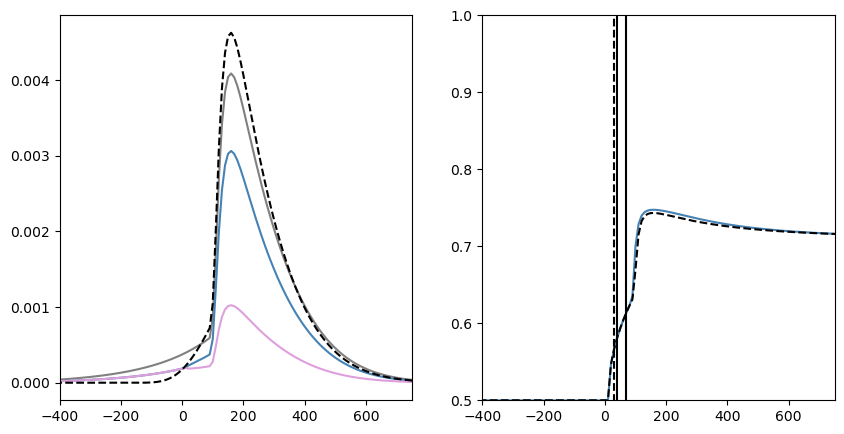

In [9]:
## Plot the pdfs and tachometric convolved

from scipy.integrate import quad_vec, simpson

ild = 2
abl = 40
out = 1.0 #outcome
t_fix = 400.

# x = [0.171142397, 30.240853, 1.22983981, 0.119605477, 92.0593483, 50., 30., 0., 0., 0.0034227695, 0.0779262977, 1.0]

# define time vector to plot the convolved pdf and tach
tt=np.arange(-700, 1000., 10)

# initialize model
t0 = tt
model = model_tach_4delays(RT=t0,ABL=abl*np.ones_like(t0),ILD=ild*np.ones_like(t0),t_fix=t_fix*np.ones_like(t0),out=out*np.ones_like(t0))
model.set_params(x)

def fun_to_integrate_pdf_and_tach(tt,t_fix):
    "This returns the pdf and tachometric multiplied by the pdf of the fixation distribution"
    model.update_data(RT=tt,ABL=abl*np.ones_like(tt),ILD=ild*np.ones_like(tt),t_fix=t_fix*np.ones_like(tt),out=out*np.ones_like(tt))  
    pdf, tach = model.pdf_and_tach()
    fix_dist = np.where(t_fix<200.,0.,np.exp(-(t_fix-200.)/200.)/200.)/(1-np.exp(-5))
    #include also correct and error pdf as 3rd and 4rd output
    return pdf*fix_dist, tach*fix_dist, pdf*tach*fix_dist, pdf*(1-tach)*fix_dist


def convolve_pdf_and_tach(tt):
    
    tfix_v = np.arange(200, 1200., 10)

    to_convolve_pdf = np.zeros((tt.size,tfix_v.size))
    to_convolve_tach = np.zeros((tt.size,tfix_v.size))
    to_convolve_pdf_cor = np.zeros((tt.size,tfix_v.size))
    to_convolve_pdf_err = np.zeros((tt.size,tfix_v.size))

    for k in range(tfix_v.size):
        to_convolve_pdf[:,k] = fun_to_integrate_pdf_and_tach(tt,tfix_v[k])[0]
        to_convolve_tach[:,k] = fun_to_integrate_pdf_and_tach(tt,tfix_v[k])[1]
        to_convolve_pdf_cor[:,k] = fun_to_integrate_pdf_and_tach(tt,tfix_v[k])[2]
        to_convolve_pdf_err[:,k] = fun_to_integrate_pdf_and_tach(tt,tfix_v[k])[3]

    convolved_pdf = simpson(to_convolve_pdf,x=tfix_v)
    convolved_tach = simpson(to_convolve_tach,x=tfix_v)
    convolved_pdf_cor = simpson(to_convolve_pdf_cor,x=tfix_v)
    convolved_pdf_err = simpson(to_convolve_pdf_err,x=tfix_v)

    return convolved_pdf, convolved_tach, convolved_pdf_cor, convolved_pdf_err


def just_pdf_and_tach(tt,t_fix):
    "This returns just the pdf and tachometric"
    model.update_data(RT=tt,ABL=abl*np.ones_like(tt),ILD=ild*np.ones_like(tt),t_fix=t_fix*np.ones_like(tt),out=out*np.ones_like(tt))
    pdf, tach = model.pdf_and_tach()
    return pdf, tach


convolved_pdf, convolved_tach, convolved_pdf_cor, convolved_pdf_err = convolve_pdf_and_tach(tt)

just_pdf, just_tach = just_pdf_and_tach(tt,t_fix)

fig, ax = plt.subplots(1,2)
fig.set_size_inches([10,5])

ax[0].plot(tt, convolved_pdf, label='pdf all', color='gray')
ax[0].plot(tt, convolved_pdf_cor, label='pdf cor', color='steelblue')
ax[0].plot(tt, convolved_pdf_err, label='pdf err', color='plum')
ax[0].plot(tt, just_pdf, label='pdf unconvolved', color='k',ls='--')
ax[0].set_xlim([-t_fix,750])

ax[1].plot(tt, convolved_tach, label='tachometric', color='steelblue')
ax[1].plot(tt, just_tach, label='tachometric unconvolved', color='k',ls='--')
ax[1].plot(tse_TIED*np.array([1,1]),np.array([0,1]),color='k')
ax[1].plot(tmotor_TIED*np.array([1,1]),np.array([0,1]),color='k',ls='--')
ax[1].plot(ndt_TIED*np.array([1,1]),np.array([0,1]),color='k')
ax[1].set_xlim([-t_fix,750])
ax[1].set_ylim([.5,1])


In [2]:
%timeit model.log_likelihood()

2.43 ms ± 109 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [3]:
%prun model.log_likelihood()

         299 function calls (298 primitive calls) in 0.004 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        4    0.001    0.000    0.001    0.000 model_tach_shift_v5.py:153(f_and_F_raw_all_tied)
        1    0.001    0.001    0.001    0.001 model_tach_shift_v5.py:219(acc_in_bounds_raw_withnorm)
        2    0.000    0.000    0.001    0.000 model_tach_shift_v5.py:361(f_and_F_RT_pa)
        1    0.000    0.000    0.003    0.003 model_tach_shift_v5.py:446(pdf_and_tach)
       40    0.000    0.000    0.000    0.000 model_tach_shift_v5.py:261(<lambda>)
       38    0.000    0.000    0.000    0.000 numeric.py:67(zeros_like)
        4    0.000    0.000    0.000    0.000 model_tach_shift_v5.py:383(<lambda>)
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
        1    0.000    0.000    0.003    0.003 model_tach_shift_v5.py:497(log_likelihood)
      2/1    0.000    0.000    0.003 

In [3]:
import numpy as np
from kreg_single import kreg_single

x1 = 1+np.random.randn((1000))
x2 = 2+np.random.randn((1000))

# RTs[0,0] = x1
# RTs[1,0] = x2

RTs = [x1,x2]

# Cs[0,0] = np.ones_like(x1)
# Cs[1,0] = np.zeros_like(x2)

Cs = [np.ones_like(x1),np.zeros_like(x2)]

# Define other necessary inputs
dx = 0.01
# Calculate xbin
xbin = np.arange(-4, dx * (np.ceil(7 / dx) + 10), dx)
xbin = xbin.T
# Calculate xxi
xxi = np.arange(-4, 7000 + 10, 10) / 1000
h = 0.01
RTmin = -4
B = 1000

print(xbin.shape, xxi.shape)

# Call the function
RTD, TCM = kreg_single(RTs, Cs, xxi, xbin, h, RTmin, B)

# Output the results
print("RTD:", RTD)
print("TCM:", TCM)





(1111,) (702,)


ValueError: operands could not be broadcast together with shapes (702,) (1111,) 